In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip drive/MyDrive/ssne_datasets/trafic_32.zip

In [ ]:
# %load_ext autoreload
# %autoreload 2

In [168]:
import os
import json
import math
import numpy as np
import pandas as pd

## Imports for plotting
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.colors import to_rgb
import matplotlib

## PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
from torch.optim import Adam

import importlib
import vae
import utils
# from utils import train, generate_random_images, save_images, save_model, corrupt

In [169]:

importlib.reload(vae)
importlib.reload(utils)

<module 'utils' from '/content/utils.py'>

In [140]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


### Bez normalizacji działa lepiej

In [ ]:
TRAIN_DATA_DIR = "trafic_32"
BATCH_SIZE = 16
OVERFIT_ON_FIRST_BATCH = False

transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.3184, 0.2927, 0.3013), (0.2763, 0.2655, 0.2686))
    ])
dataset = ImageFolder(TRAIN_DATA_DIR, transform=transform)
loader = DataLoader(
    dataset,
    BATCH_SIZE,
    shuffle=not OVERFIT_ON_FIRST_BATCH,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

In [142]:
number_of_classes = 43
all_classes = np.arange(number_of_classes, dtype=int)
class_to_idx = {c: i for i, c in enumerate(all_classes)}

idx = torch.tensor([class_to_idx[x] for x in all_classes])

onehot = nn.functional.one_hot(idx, num_classes=len(all_classes)).to(device)

print(onehot[torch.tensor([0, 1, 2])])

tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]],
       device='cuda:0')


In [143]:
for images, labels in loader:
    print(images.shape)  # [batch_size, 3, 32, 32]
    print(labels.shape)  # [batch_size]
    break

torch.Size([16, 3, 32, 32])
torch.Size([16])


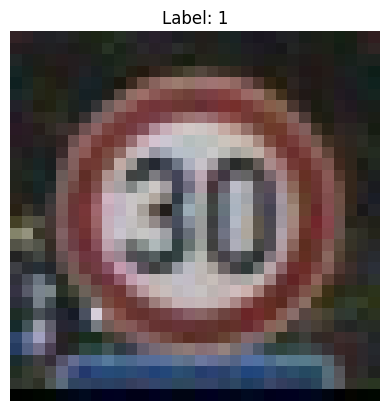

In [145]:
image, label = dataset[502]
# image = (utils.unnormalize(image)).squeeze()
plt.imshow(image.permute(1, 2, 0))
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

Input shape: torch.Size([8, 3, 32, 32])


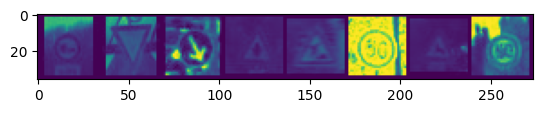

In [146]:
x, y = next(iter(loader))
x = x[:8]
print('Input shape:', x.shape)
plt.imshow(torchvision.utils.make_grid(x)[0]);

### Liniowy działa lepiej niż konwolucyjny

In [164]:
vae_m = vae.VAE(
    input_dim=3 * 32 * 32,
    hidden_dim=1024,
    latent_dim=128,
    output_dim=3 * 32 * 32,
    condition_size=onehot.shape[0],
).to(device)
optimizer = Adam(vae_m.parameters(), lr=0.0003)
vae_m


VAE(
  (encoder): Encoder(
    (fc1): Linear(in_features=3115, out_features=1024, bias=True)
    (fc2): Linear(in_features=1024, out_features=1024, bias=True)
    (fc_mean): Linear(in_features=1024, out_features=128, bias=True)
    (fc_log_std): Linear(in_features=1024, out_features=128, bias=True)
    (lrelu): LeakyReLU(negative_slope=0.3)
  )
  (decoder): Decoder(
    (fc1): Linear(in_features=171, out_features=1024, bias=True)
    (fc2): Linear(in_features=1024, out_features=1024, bias=True)
    (fc3): Linear(in_features=1024, out_features=3072, bias=True)
    (lrelu): LeakyReLU(negative_slope=0.3)
  )
)

In [ ]:
Cvae = vae.ConvVAE(
    in_channels=3,
    latent_dim=128,
    condition_size=onehot.shape[0],
).to(device)
optimizer = Adam(Cvae.parameters(), lr=0.0003)
Cvae


In [ ]:
# Do FID
import torchvision.models as models
inception = models.inception_v3(pretrained=True, transform_input=False)
inception.fc = torch.nn.Identity()
inception.eval()
inception = inception.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 184MB/s] 


In [ ]:
real_features = utils.get_features(loader, inception, device)

In [ ]:
# Proporcjonalny rozkład klas do generowania

import math

num_imgs = 1000

targets = np.array(dataset.targets)

# count per class
counts = np.bincount(targets)
total = counts.sum()
dist = []

for c in counts:
  dist.append(c/total)

print(np.array(dist).sum())

y_to_generate = []

i = 0
for d in dist:
  for _ in range(math.ceil(d*num_imgs)):
    y_to_generate.append(i)
  i+=1


diff = len(y_to_generate) - num_imgs
assert diff > 0

x=torch.tensor(y_to_generate, dtype=int).to(device)
perm = torch.randperm(x.size(0))

keep_idx = perm[diff:]   # drop first N shuffled elements
classes = x[keep_idx].to(device)
assert classes.shape[0] == num_imgs

print(classes.shape)

1.0
torch.Size([1000])


In [166]:
class GenDataset(torch.utils.data.Dataset):
    def __init__(self, imgs):
        self.imgs = imgs
    def __len__(self):
        return len(self.imgs)
    def __getitem__(self, idx):
        return self.imgs[idx], 0

In [ ]:
epizods = 20
EPOCHS = 5
losses = []
best_FID = float('inf')

for e in range(epizods):
  utils.train(
      model=vae_m,
      optimizer=optimizer,
      loader=loader,
      onehot=onehot,
      overfit_on_single_batch=OVERFIT_ON_FIRST_BATCH,
      epochs=EPOCHS,
      show_every=5,
      losses_list=losses,
      device=device,
  )

  threshold_images = utils.generate_random_images(
    model=vae_m,
    onehot=onehot,
    classes=classes,
    num_imgs=num_imgs,
    device=device
  )

  threshhold_dataset = GenDataset(threshold_images)
  threshhold_loader = torch.utils.data.DataLoader(threshhold_dataset, batch_size=64)
  threshhold_features = utils.get_features(threshhold_loader, inception, device)

  fid_score = utils.calculate_frechet_distance(real_features, threshhold_features)
  print(f"FID: {e}: ->:", fid_score)

  if fid_score < best_FID:
    best_FID = fid_score
    utils.save_model(Cvae, "output/v1_best_so_far.pt")

plt.plot(losses)
plt.show()

In [ ]:
# save_model(vae, "output/vae_model.pt")

In [ ]:
state_dict = torch.load("output/vae_model.pt", map_location=device)

vae.load_state_dict(state_dict)

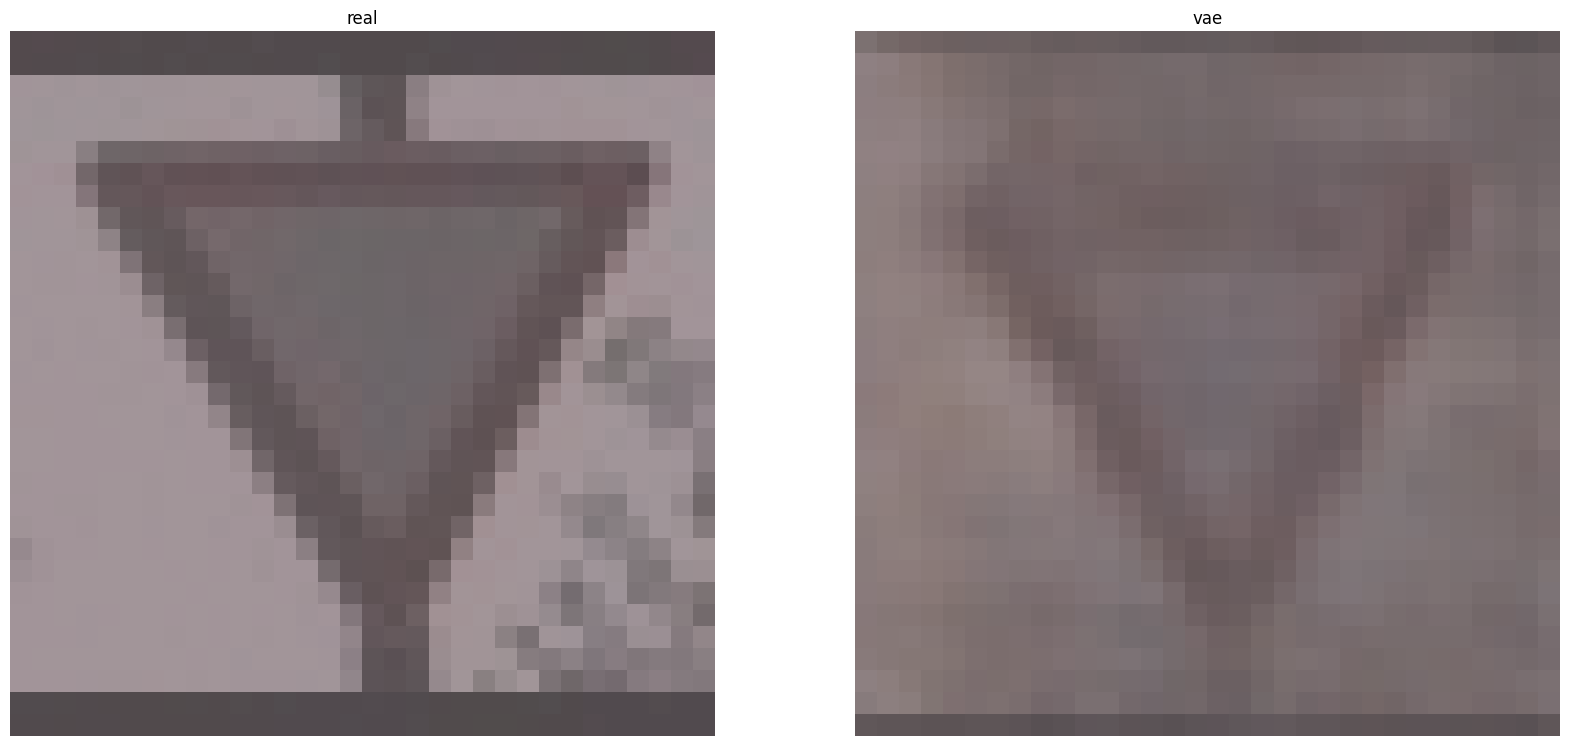

In [159]:
_, axs = plt.subplots(1, 2, figsize=(20, 10))
img, label = next(iter(loader))
img = utils.unnormalize(img)
recon = Cvae(img.to(device), onehot[label].to(device))[0]
recon = utils.unnormalize(recon)
axs[1].axis("off")
axs[1].imshow(recon[0].permute(1, 2, 0).cpu().detach())
axs[1].set_title("vae")
axs[0].imshow(img[0].permute(1, 2, 0).cpu().detach())
axs[0].set_title("real")
axs[0].axis("off")
plt.show()

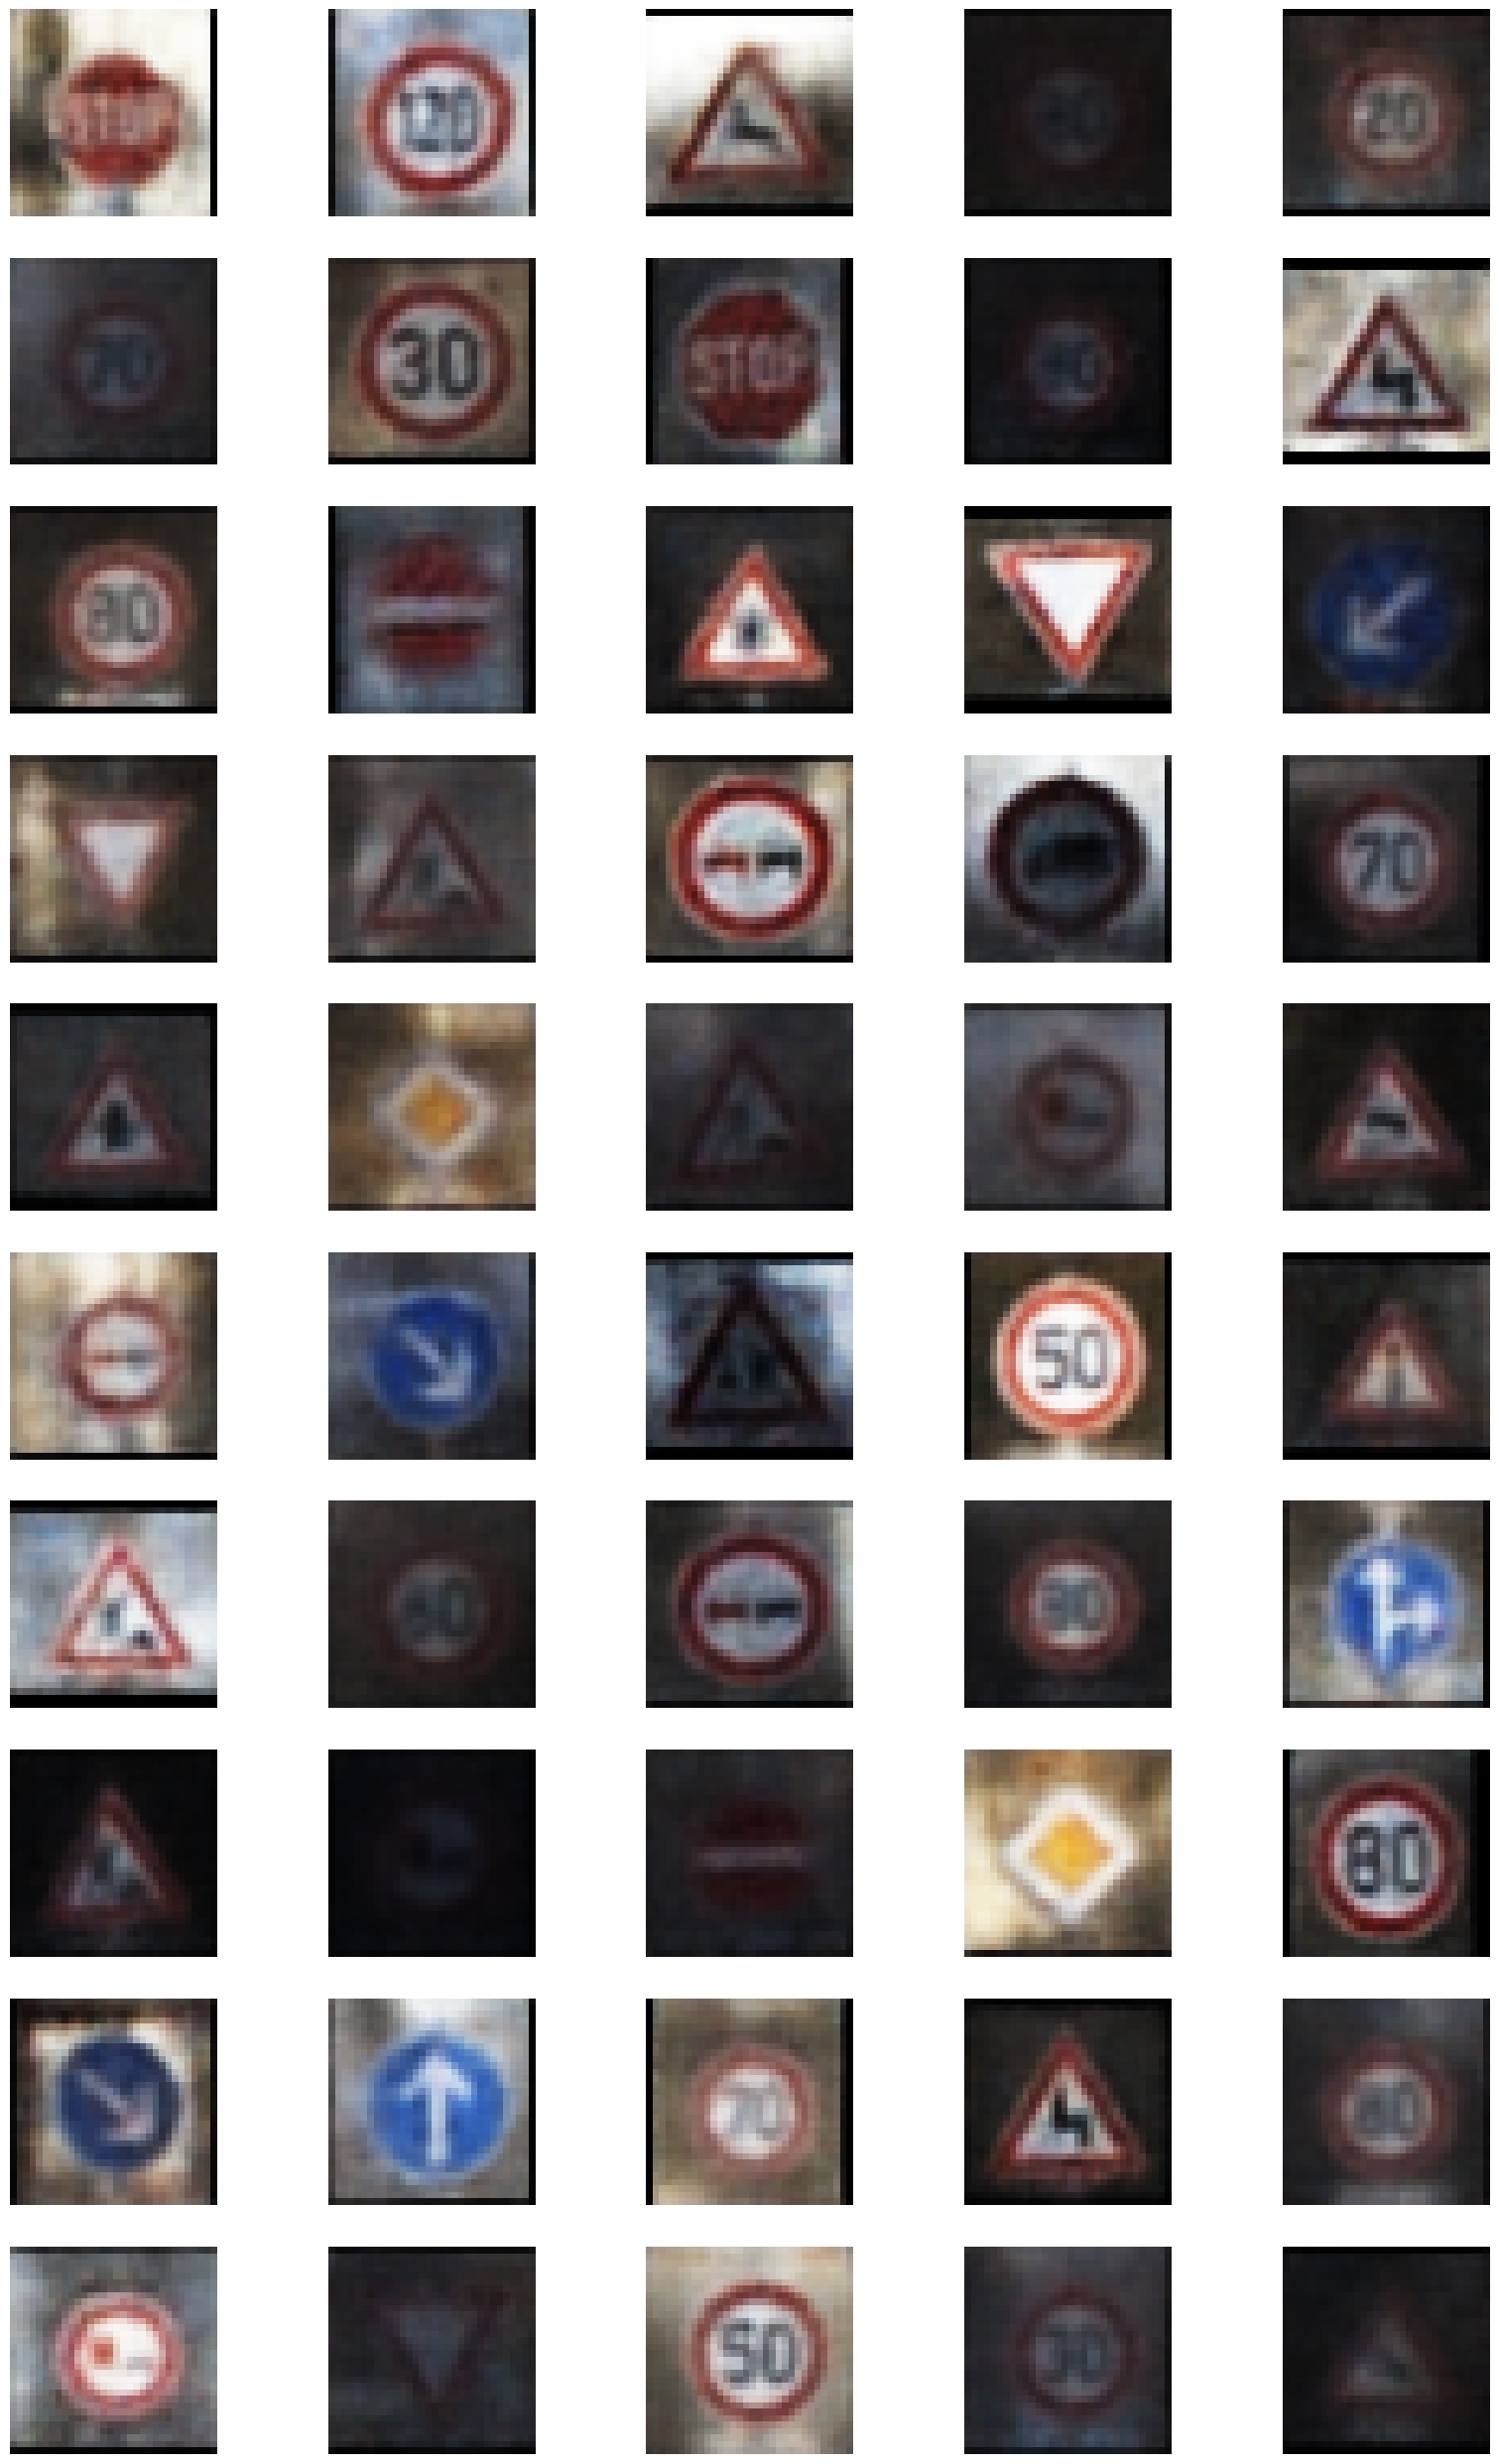

In [160]:
generated_images = utils.generate_random_images(
    model=Cvae,
    onehot=onehot,
    classes=classes,
    num_imgs=num_imgs,
    device=device)
_, axs = plt.subplots(10, 5, figsize=(20, 32))
axs = axs.flatten()
i=0
for a, img in zip(axs, generated_images):
    a.imshow(img.permute(1, 2, 0).cpu().detach())
    a.axis("off")
    i+=1
    if i > 50:
      break
plt.show()

In [ ]:
# assert generated_images.shape[0] == 1000
# utils.save_images(generated_images, "output/generated_vae_FID=45.pt")

In [161]:
print(generated_images.shape)
gen_dataset = GenDataset(generated_images)
gen_loader = torch.utils.data.DataLoader(gen_dataset, batch_size=64)
gen_features = utils.get_features(gen_loader, inception, device)


torch.Size([1000, 3, 32, 32])


In [162]:
print(real_features.shape)
print(gen_features.shape)

(39209, 2048)
(1000, 2048)


In [ ]:
fid_score = utils.calculate_frechet_distance(real_features, gen_features)
print("FID:", fid_score)

FID: 43.009417197252475
